# Multiscale patch pipeline

Closes Layer Gate 2: proves the pyramid + patch extraction/reconstruction
machinery works on a real EMPS image, not just a synthetic toy array, and
that no stored patch touches an excluded (figure-furniture) pixel at any
scale.


## 1. Load a real source image

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
from data.loader import DEV_SOURCE_IDS, load_generator_source

img, source_id = load_generator_source(DEV_SOURCE_IDS[0])
print(f"loaded {source_id}, shape={img.shape}, dtype={img.dtype}")


loaded 00655d9628, shape=(515, 512), dtype=uint8


## 2. Build the multiscale pyramid

Defined by scale factors, not fixed pixel sizes, so it works on any of
EMPS's 218 distinct canvas geometries.

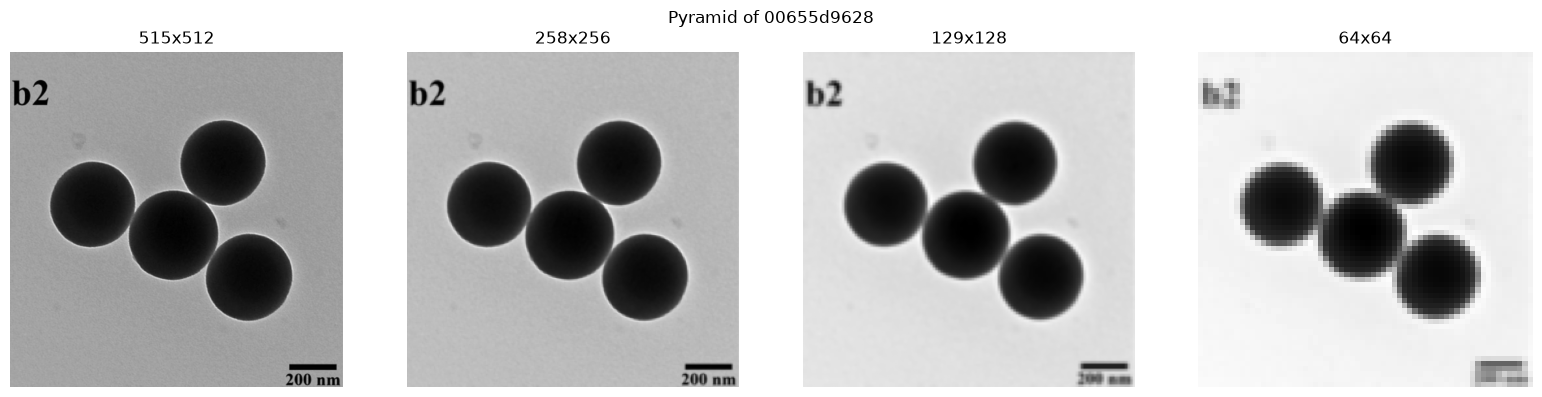

In [2]:
import matplotlib.pyplot as plt
from data.pyramid import build_pyramid

NUM_SCALES = 4
levels = build_pyramid(img, num_scales=NUM_SCALES, scale_factor=0.5)

fig, axes = plt.subplots(1, NUM_SCALES, figsize=(4 * NUM_SCALES, 4))
for ax, level_img in zip(axes, levels):
    ax.imshow(level_img, cmap="gray")
    ax.set_title(f"{level_img.shape[0]}x{level_img.shape[1]}")
    ax.axis("off")
plt.suptitle(f"Pyramid of {source_id}")
plt.tight_layout()
plt.show()


## 3. Extract patches at every scale, with exclusion applied

The exclusion mask is rebuilt at each level's own resolution (border
fraction, extreme-intensity, and line detection all scale naturally with
image size) - a patch is dropped if it touches any excluded pixel.

In [3]:
import pandas as pd
from data.furniture import build_exclusion_mask
from data.patches import extract_patches, reconstruct_from_patches, assert_no_excluded_patch

PATCH_SIZE = 8
STRIDE = 4

rows = []
records_by_level = []

for level, level_img in enumerate(levels):
    mask = build_exclusion_mask(level_img)
    unfiltered = extract_patches(level_img, PATCH_SIZE, STRIDE)
    filtered = extract_patches(level_img, PATCH_SIZE, STRIDE, exclusion_mask=mask)
    assert_no_excluded_patch(filtered, mask)
    records_by_level.append(filtered)

    rows.append({
        "level": level,
        "shape": f"{level_img.shape[0]}x{level_img.shape[1]}",
        "patches_before_exclusion": len(unfiltered.positions),
        "patches_after_exclusion": len(filtered.positions),
        "dropped_by_furniture_mask": len(unfiltered.positions) - len(filtered.positions),
    })

patch_count_table = pd.DataFrame(rows)
patch_count_table


,level,shape,patches_before_exclusion,patches_after_exclusion,dropped_by_furniture_mask
0,0,515x512,16256,13210,3046
1,1,258x256,4032,2706,1326
2,2,129x128,992,556,436
3,3,64x64,225,105,120


## 4. Reconstruction check on the real image

Patches extracted at full resolution (level 0, no exclusion) must
reconstruct the original image exactly - this is the correctness gate, on
real data rather than a synthetic array.

In [4]:
full_res_record = extract_patches(img, PATCH_SIZE, STRIDE)
rebuilt = reconstruct_from_patches(full_res_record, img.shape)

import numpy as np
max_error = np.abs(img.astype(np.float64) - rebuilt).max()
assert max_error < 1e-8, f"reconstruction error too large: {max_error}"
print(f"reconstruction check passed on real image {source_id}: max pixel error = {max_error:.2e}")


reconstruction check passed on real image 00655d9628: max pixel error = 0.00e+00


## Layer Gate 2 -> 3: status

- [x] pyramid + patch datasets are reproducible for a valid source image (real EMPS image, not just a toy array)
- [x] the original image can be reconstructed exactly from its extracted patches (max error < 1e-8)
- [x] no stored patch at any scale touches an excluded (figure-furniture) pixel

All Layer 2 gate conditions are met. Layer 3 (closed-form patch denoiser) may begin.
